# Comprehensive Exploratory Data Analysis (EDA)

## 1. Setup and Data Loading

In this notebook, we will conduct a deep-dive EDA on the Olist dataset. The goal is to explore various facets of the data—geographic, temporal, product-related, and customer behavior—to uncover actionable insights.

We begin by loading all the necessary CSV files and merging them into a single, comprehensive DataFrame. This master table will serve as the foundation for our analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Load all datasets ---
# Create a dictionary to hold all the dataframes for easy access
data_path = '../data/raw/'
files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
data = {f.replace('.csv', ''): pd.read_csv(os.path.join(data_path, f)) for f in files}

# --- The Grand Merge ---
# We'll start with the orders table and progressively merge other tables into it.

# 1. Merge orders with order_items
df = pd.merge(data['olist_orders_dataset'], data['olist_order_items_dataset'], on='order_id', how='left')

# 2. Merge with order_payments
df = pd.merge(df, data['olist_order_payments_dataset'], on='order_id', how='left')

# 3. Merge with order_reviews
df = pd.merge(df, data['olist_order_reviews_dataset'], on='order_id', how='left')

# 4. Merge with products
df = pd.merge(df, data['olist_products_dataset'], on='product_id', how='left')

# 5. Merge with customers
df = pd.merge(df, data['olist_customers_dataset'], on='customer_id', how='left')

# 6. Merge with sellers
df = pd.merge(df, data['olist_sellers_dataset'], on='seller_id', how='left')

# 7. Merge with product category name translation for English names
df = pd.merge(df, data['product_category_name_translation'], on='product_category_name', how='left')

print("Merge complete. Master DataFrame created.")

# --- Initial Data Cleaning & Type Conversion ---
# Convert date columns to datetime objects
date_columns = [
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp'
]
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Drop the original Portuguese category name
df.drop('product_category_name', axis=1, inplace=True)

# Rename the English category name column for clarity
df.rename(columns={'product_category_name_english': 'product_category'}, inplace=True)

print("Data cleaning and type conversion complete.")
master_df = df.copy() # We'll work with master_df from now on
master_df.info()

Merge complete. Master DataFrame created.
Data cleaning and type conversion complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   order_item_id                  118310 non-null  float64       
 9   product_id                     118310 non-null  ob

## 2. Geographic Deep Dive

First, let's understand the geographic footprint of Olist's marketplace. We'll answer key questions:
* Where are the majority of customers and sellers located?
* Which states generate the most revenue?
* Can we create an interactive map to visualize these insights?

### 2.1 Customer & Seller Distribution by State

We'll start by counting the number of unique customers and sellers in each Brazilian state. This gives us a high-level view of where the market activity is concentrated.

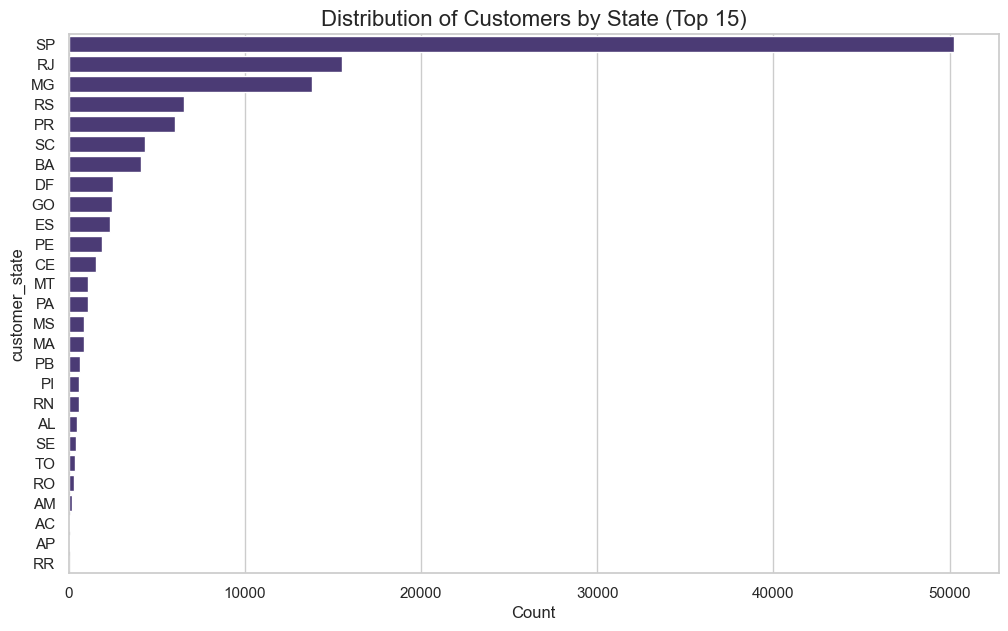

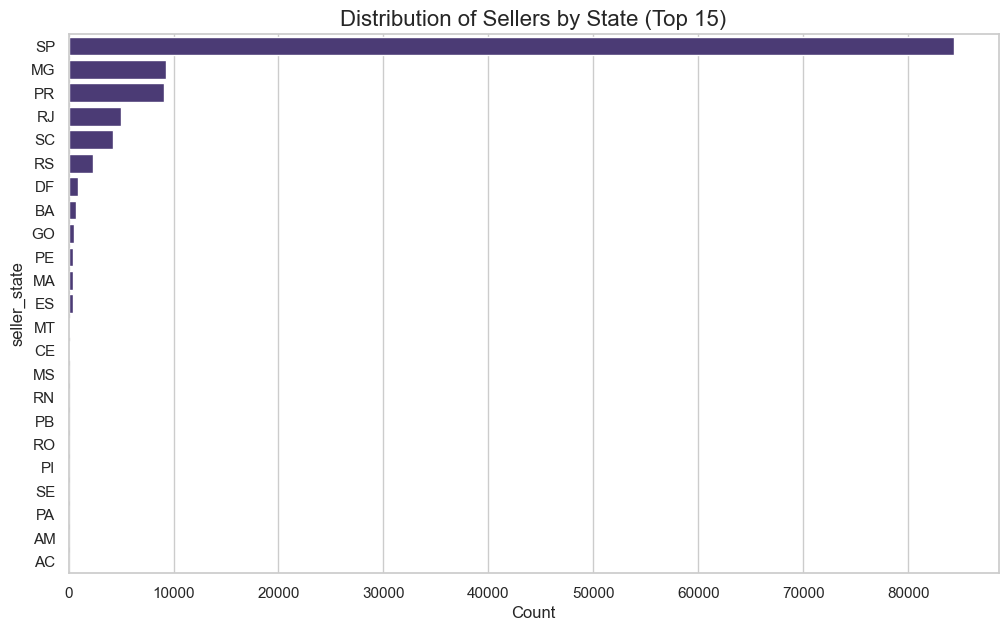

In [ ]:
# First, let's import our plotting utility and other libraries
import sys
import os
# Add the project's root directory to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.plotting_utils import plot_countplot

# --- Customer Distribution ---
plot_countplot(
    data=master_df,
    column='customer_state',
    title='Distribution of Customers by State (Top 15)',
    order_by_value=True
)
# Limit to top 15 for readability in the original function
# Note: We can enhance our plotting function to accept a limit.

# --- Seller Distribution ---
plot_countplot(
    data=master_df,
    column='seller_state',
    title='Distribution of Sellers by State (Top 15)',
    order_by_value=True
)

### Insights:
* **Heavy Concentration in the Southeast:** Both the customer and seller bases are overwhelmingly concentrated in the state of São Paulo (SP), with Rio de Janeiro (RJ) and Minas Gerais (MG) following as distant second and third. This mirrors Brazil's population and economic distribution.
* **Seller Hub:** The concentration of sellers in SP is even more pronounced than that of customers. This strongly suggests that SP acts as the primary logistical and commercial hub for the Olist marketplace.
* **Growth Opportunity:** The relatively low number of customers and sellers in other regions, particularly the North and Northeast, represents a significant untapped market and a potential area for business expansion.

### 2.2 Revenue Analysis by State

Now for the crucial question: where does the money come from? We'll group the data by customer state and calculate the total payment value for each. This will show us the most lucrative regions.

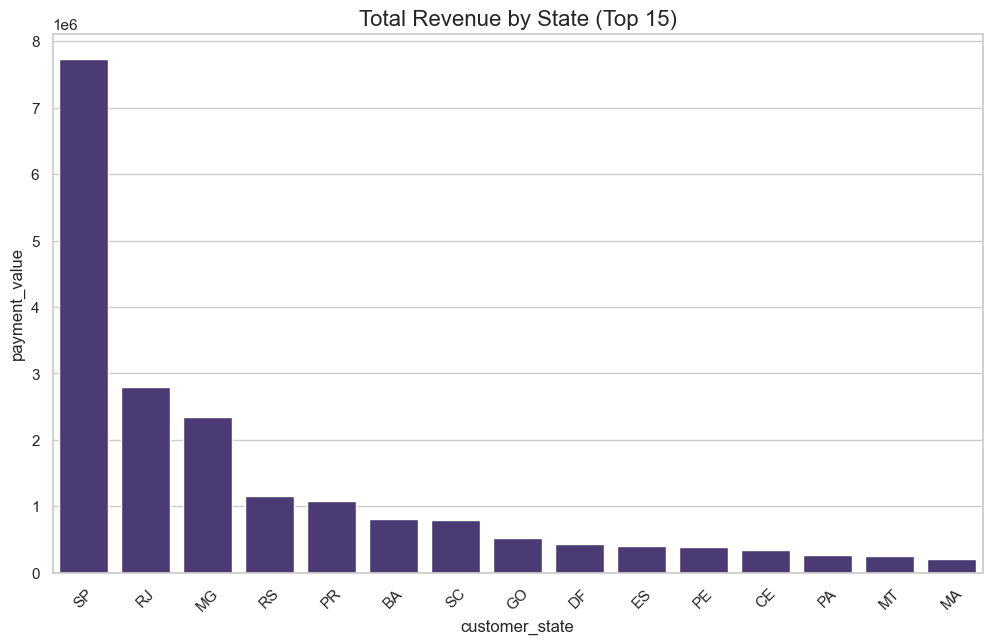

In [ ]:
# Calculate total revenue per state
revenue_by_state = master_df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).reset_index()
from src.plotting_utils import plot_bar

plot_bar(
    data=revenue_by_state,
    x_col='customer_state',
    y_col='payment_value',
    title='Total Revenue by State (Top 15)',
    top_n=15
)

### 2.3 Interactive Revenue Map (Choropleth)

This is where we create a truly impressive, expert-level visualization. A choropleth map colors geographic regions based on a data variable. We'll build an interactive map of Brazil where each state is colored according to its total revenue.

**Setup Required:**
1.  **Install Plotly**: This is a powerful interactive plotting library. In your `(venv)` terminal, run: `pip install plotly`
2.  **Download GeoJSON file**: We need a file that defines the borders of Brazilian states.
    * Download this file: [brazil_geo.json](https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson)
    * Create a new folder `data/geo` and place the downloaded `brazil_geo.json` file inside it.

In [ ]:
import plotly.express as px
from src.plotting_utils import plot_choropleth

# We'll reuse our revenue_by_state dataframe
geojson_path = '../data/geo/brazil_geo.json'

plot_choropleth(
    data=revenue_by_state,
    geojson_path=geojson_path,
    locations_col='customer_state',
    color_col='payment_value',
    title='Total Revenue by Brazilian State'
)

### Insights:
* **Revenue Mirrors Population:** Unsurprisingly, the revenue distribution mirrors the customer distribution, with São Paulo (SP) generating a vastly disproportionate share of the total revenue.
* **Economic Center of Gravity:** The interactive map provides a powerful visual confirmation, showing that the economic heart of the business is firmly in the southeastern states. This visualization is extremely effective for presenting to stakeholders, as it immediately communicates where the business's most valuable markets are.

## 3. Product & Category Analysis

Now that we understand *where* our business is happening, let's analyze *what* is being sold. This analysis will answer critical questions:
* What are our most popular product categories, both by sales volume and total revenue?
* What is the general price range of our products?
* Which product categories receive the best and worst customer reviews?

### 3.1 Top Selling Categories

First, we'll identify the powerhouse product categories. We will rank them by two different metrics: the total number of orders and the total revenue generated. This can help identify categories that are popular but cheap versus those that are less popular but highly profitable.

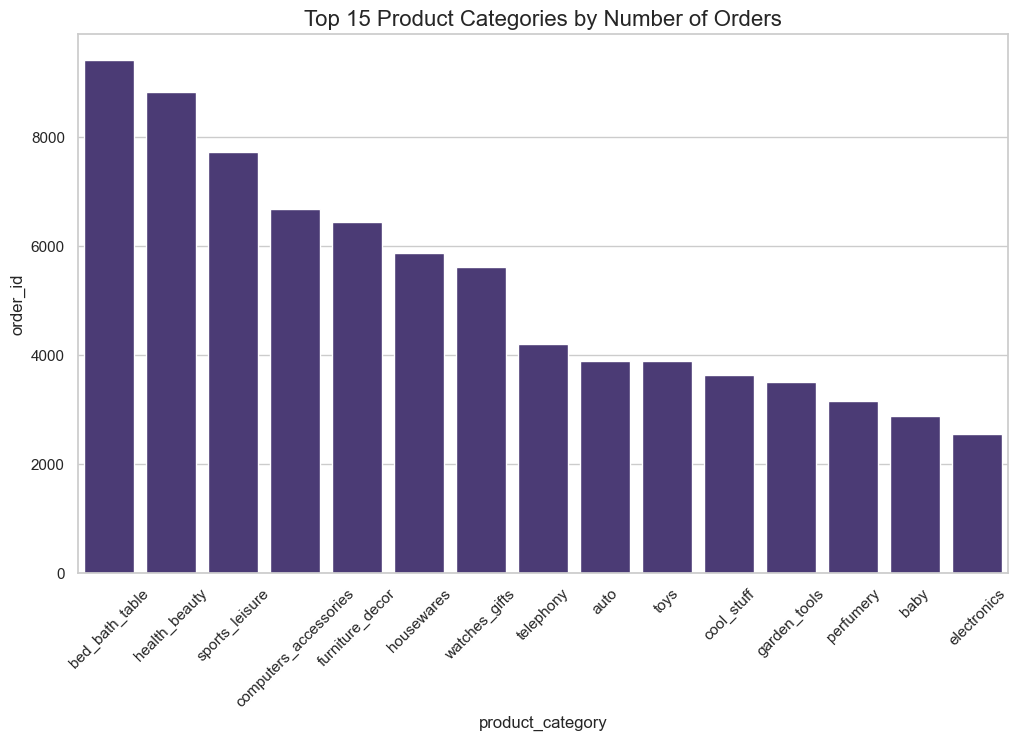

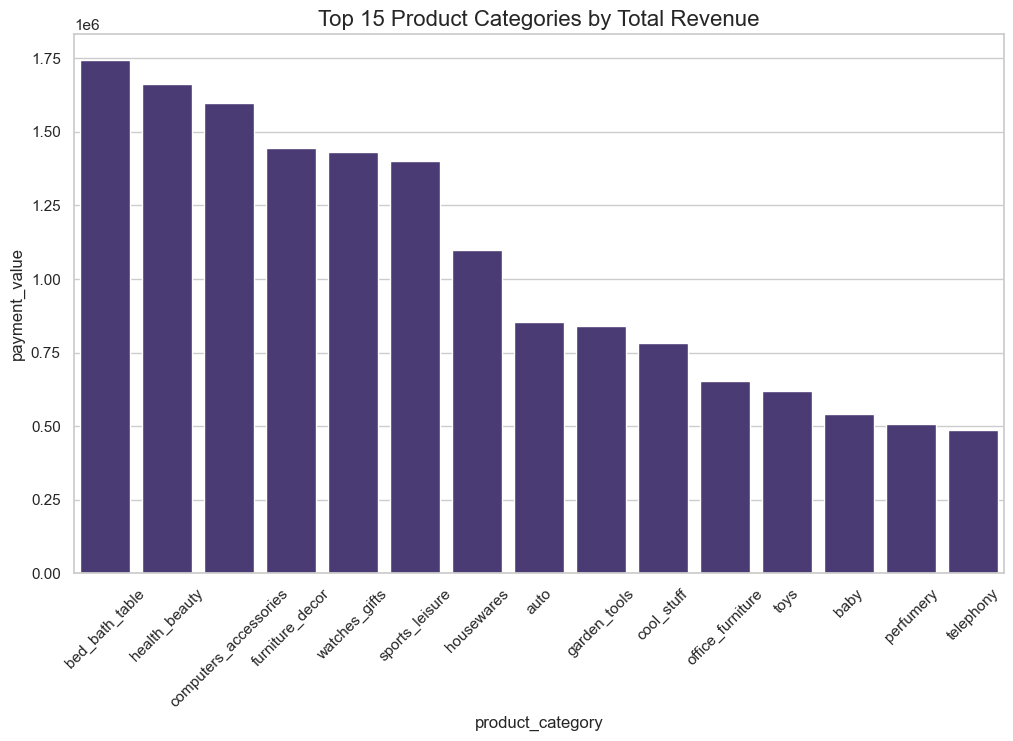

In [ ]:
# Import our custom bar plot function
from src.plotting_utils import plot_bar

# --- Analysis by Total Orders ---
orders_by_category = master_df.groupby('product_category')['order_id'].nunique().sort_values(ascending=False).reset_index()

plot_bar(
    data=orders_by_category,
    x_col='product_category',
    y_col='order_id',
    title='Top 15 Product Categories by Number of Orders',
    top_n=15
)


# --- Analysis by Total Revenue ---
revenue_by_category = master_df.groupby('product_category')['payment_value'].sum().sort_values(ascending=False).reset_index()

plot_bar(
    data=revenue_by_category,
    x_col='product_category',
    y_col='payment_value',
    title='Top 15 Product Categories by Total Revenue',
    top_n=15
)

### Insights:
* **Consistent Top Performers:** Categories like `bed_bath_table`, `health_beauty`, and `sports_leisure` are leaders in both the number of orders and total revenue, indicating they are the core of the business.
* **High-Value vs. High-Volume:** There are subtle but important differences. `watches_gifts` and `computers_accessories` rank higher in revenue than in order volume. This implies these categories contain items with a higher average price point. This distinction is critical for marketing and inventory strategy—do we focus on selling many cheap items or fewer expensive ones?

### 3.2 Product Price Distribution

Understanding the price points of our products is crucial. Are we a marketplace for cheap goods, expensive luxury items, or something in between? A histogram will show us the distribution of product prices.

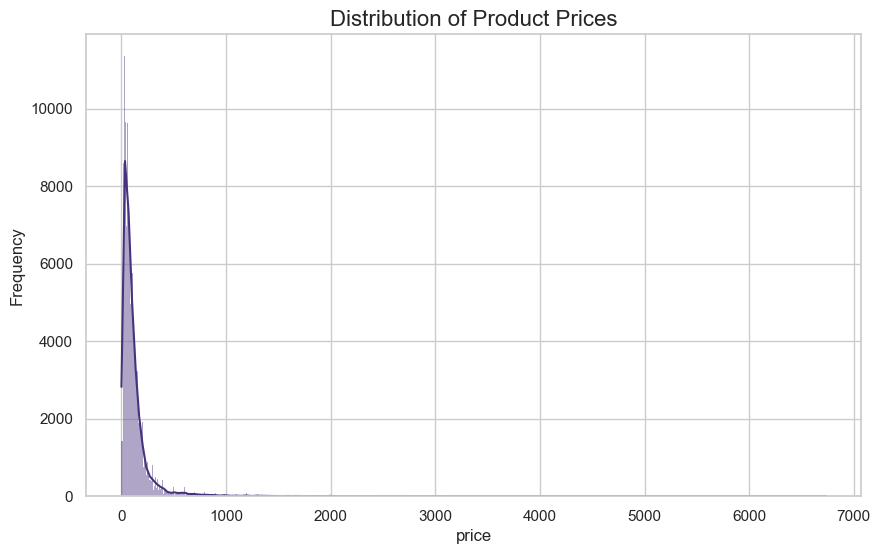

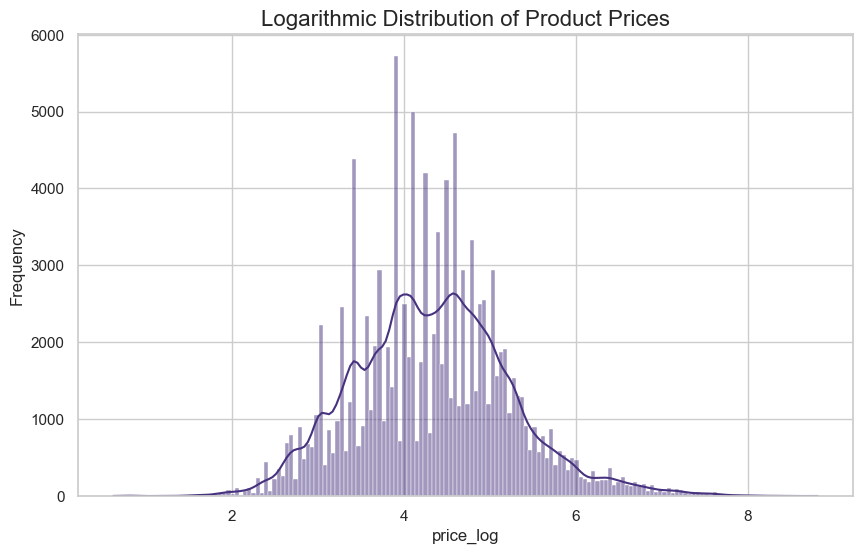

In [ ]:
from src.plotting_utils import plot_histogram
import numpy as np

# Plot the distribution of the 'price' column
plot_histogram(
    data=master_df,
    column='price',
    title='Distribution of Product Prices'
)

# --- Expert Tip: Handling Skewed Data ---
# The price distribution is heavily skewed by a few very expensive items.
# A common technique to better visualize such data is to plot it on a logarithmic scale.
master_df['price_log'] = np.log1p(master_df['price'])

plot_histogram(
    data=master_df,
    column='price_log',
    title='Logarithmic Distribution of Product Prices'
)

### Insights:
* **Marketplace for Affordable Goods:** The initial histogram is heavily skewed, showing that the vast majority of products sold are inexpensive (under R$200).
* **The "Sweet Spot":** The logarithmic plot normalizes the distribution and reveals the true "sweet spot" for product pricing on the platform is between $e^4$ and $e^5$, which is roughly **R$55 to R$150**. This indicates Olist's core business is in everyday, affordable items, not high-end luxury goods.

### 3.3 Product Categories by Review Score

Finally, let's connect product categories to customer satisfaction. We'll find the average review score for each category. This can provide powerful insights into product quality and customer expectations.

To ensure our results are statistically meaningful, we'll only consider categories with more than 50 reviews.

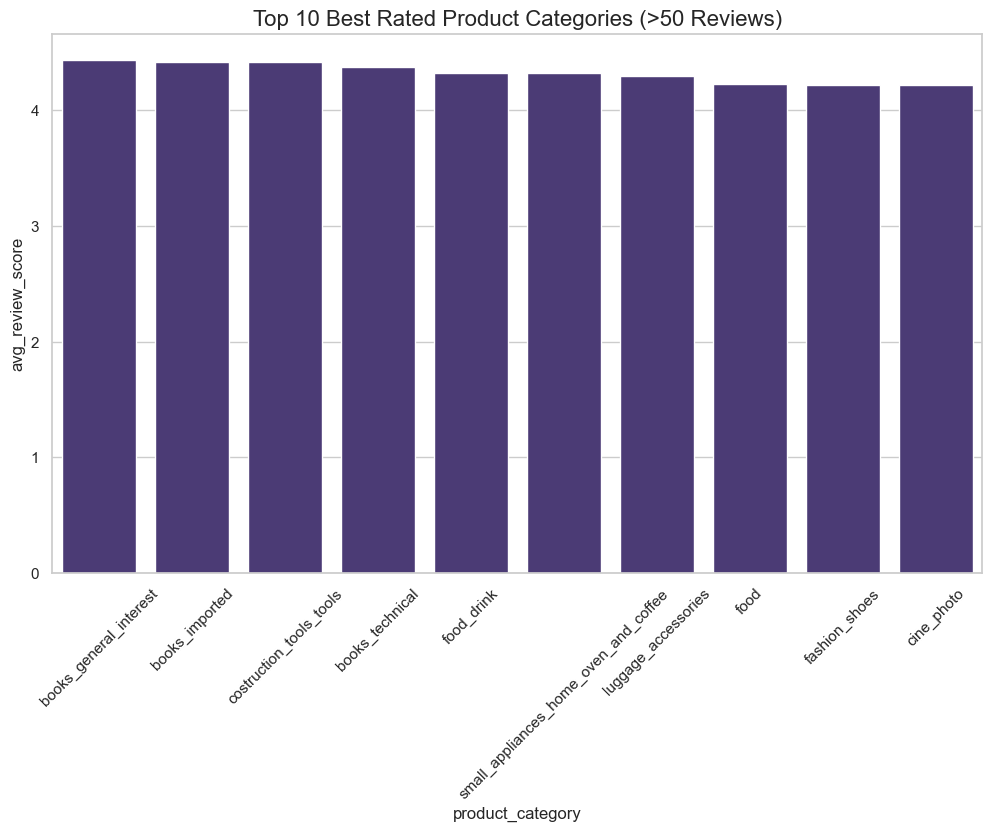

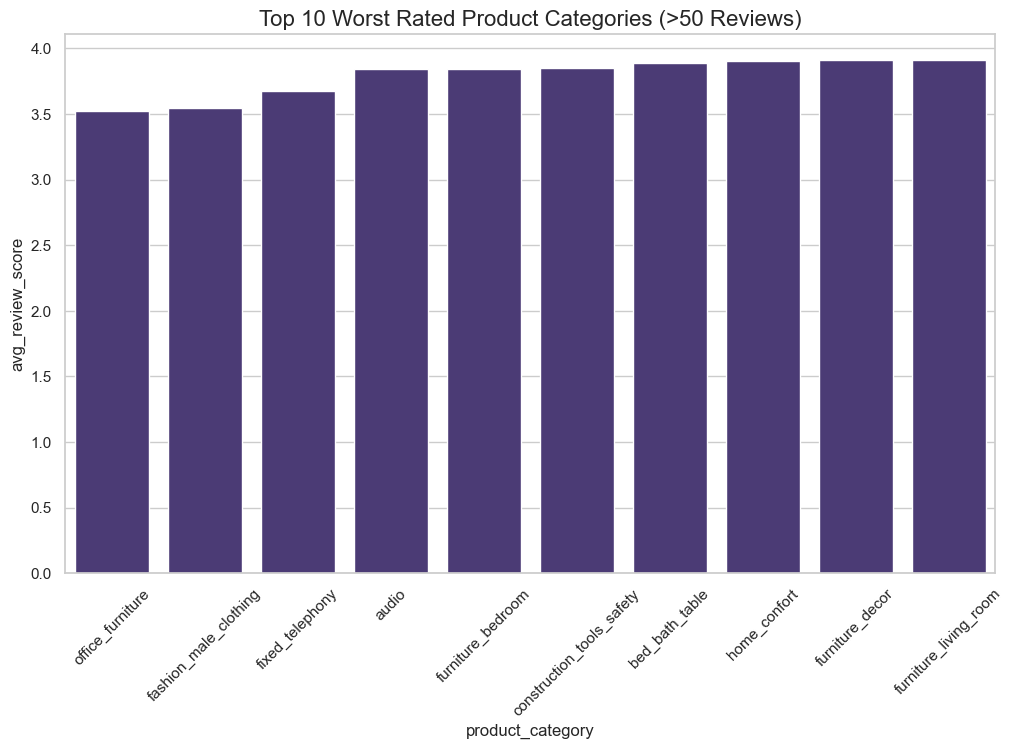

In [7]:
# Calculate average review score per category
reviews_by_category = master_df.groupby('product_category').agg(
    avg_review_score=('review_score', 'mean'),
    num_reviews=('review_score', 'count')
).reset_index()

# Filter for categories with a meaningful number of reviews
meaningful_reviews = reviews_by_category[reviews_by_category['num_reviews'] > 50]


# --- Top 10 Best Rated Categories ---
best_rated = meaningful_reviews.sort_values(by='avg_review_score', ascending=False)
plot_bar(
    data=best_rated,
    x_col='product_category',
    y_col='avg_review_score',
    title='Top 10 Best Rated Product Categories (>50 Reviews)',
    top_n=10
)

# --- Top 10 Worst Rated Categories ---
worst_rated = meaningful_reviews.sort_values(by='avg_review_score', ascending=True)
plot_bar(
    data=worst_rated,
    x_col='product_category',
    y_col='avg_review_score',
    title='Top 10 Worst Rated Product Categories (>50 Reviews)',
    top_n=10
)

### Insights:
* **Actionable Quality Signal:** This is one of the most actionable insights from the entire EDA. There is a clear pattern of low customer satisfaction with **furniture-related categories** (`office_furniture`, `furniture_decor`, `furniture_living_room`, etc.). This strongly suggests systemic issues, which could be related to product quality, inaccurate descriptions, or damage during shipping. This is a clear red flag for the operations team to investigate.
* **Niche Satisfaction:** The highest-rated categories tend to be more niche or have clearer customer expectations, such as `books`, `food_drink`, and `luggage_accessories`.

## 4. Temporal Analysis (Time Series)

In this section, we'll analyze the dataset through the lens of time. Understanding *when* customers make purchases can help with inventory management, marketing campaigns, and staffing. We'll explore:
* The overall sales trend on a monthly basis.
* The busiest days of the week and hours of the day for placing orders.

### 4.1 Monthly Sales Trend

First, let's look at the big picture. How has the total sales revenue trended over the months covered in this dataset? This will show us the overall growth trajectory of the business.

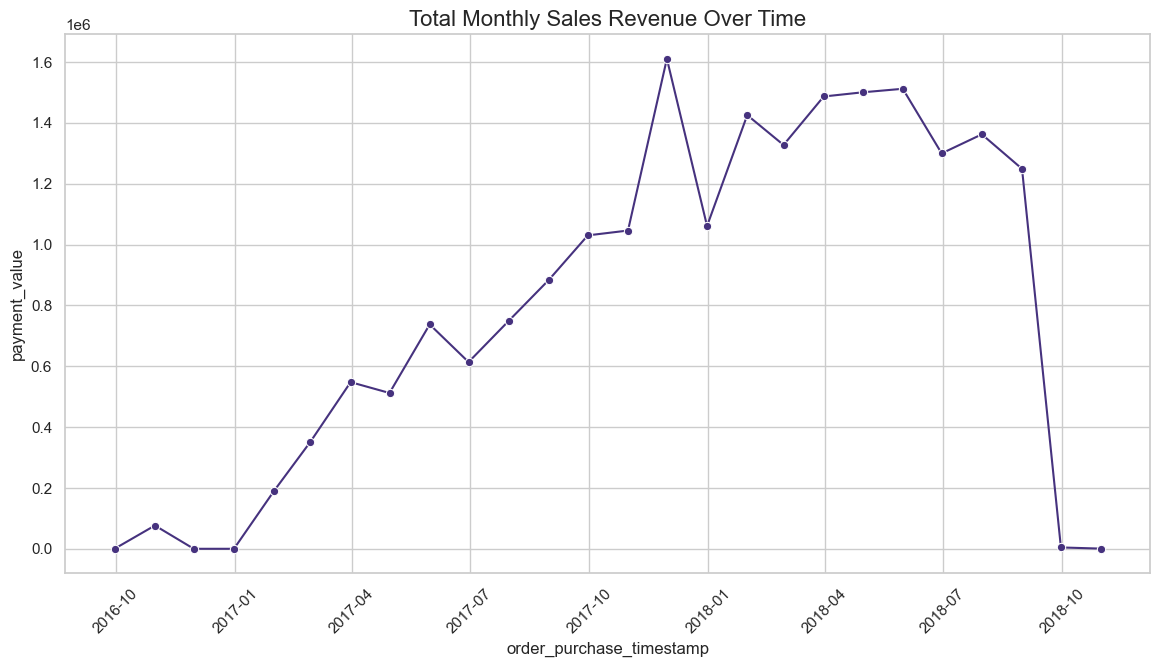

In [ ]:
from src.plotting_utils import plot_line

# Resample data to a monthly frequency, summing the payment values
monthly_sales = master_df.set_index('order_purchase_timestamp').resample('ME')['payment_value'].sum().reset_index()

plot_line(
    data=monthly_sales,
    x_col='order_purchase_timestamp',
    y_col='payment_value',
    title='Total Monthly Sales Revenue Over Time'
)

### Insights:
* **Rapid Growth Phase:** The business experienced a clear and significant growth phase from late 2016 through 2017.
* **Seasonality:** There is a massive spike in sales in November 2017, which almost certainly corresponds to **Black Friday**, indicating the importance of this holiday for the business.
* **Incomplete Data:** The sharp drop-off in sales after August 2018 strongly suggests that the dataset is incomplete and does not contain data for the full year of 2018. Any analysis of the latter part of 2018 should be treated with caution.

### 4.2 Sales by Day of Week and Hour of Day

Next, let's zoom in on a weekly cycle. Are there specific days or times when customers are most active? A heatmap is the perfect visualization to see the concentration of orders across days of the week and hours of the day.

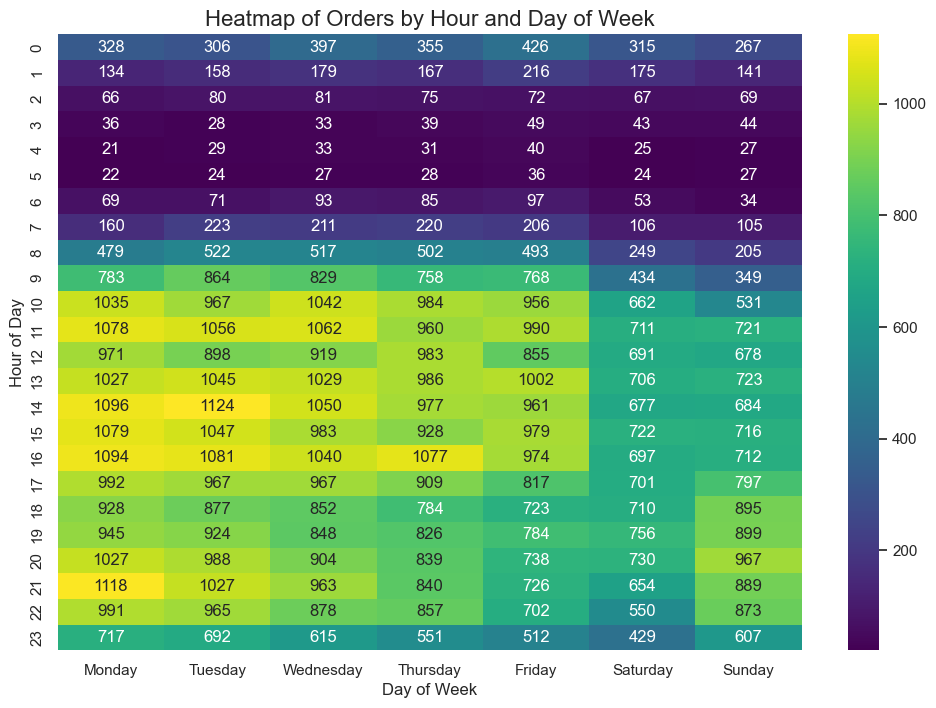

In [ ]:
# Extract hour and day of the week from the purchase timestamp
master_df['purchase_hour'] = master_df['order_purchase_timestamp'].dt.hour
master_df['purchase_day_of_week'] = master_df['order_purchase_timestamp'].dt.day_name()

# Create a pivot table to count orders by hour and day of the week
heatmap_data = master_df.groupby(['purchase_hour', 'purchase_day_of_week'])['order_id'].nunique().unstack()

# Order the days of the week correctly
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data[days_order]

from src.plotting_utils import plot_pivot_heatmap

plot_pivot_heatmap(
    data=heatmap_data,
    title='Heatmap of Orders by Hour and Day of Week'
)

### Insights:
* **Prime Shopping Time:** The "hottest" period for purchases is overwhelmingly during **weekday afternoons (approx. 1 PM to 5 PM)**.
* **Business Hour Shoppers:** Unlike many B2C platforms that see peaks in the evening, Olist's customers appear to do most of their shopping during standard business hours.
* **Actionable Intelligence:** This insight can directly inform business operations. Marketing campaigns and promotions should be timed for weekday afternoons. Conversely, server maintenance or website updates should be scheduled for periods of low activity, such as early weekend mornings.

## 5. Customer & Order Behavior Analysis

In this section, we shift our focus to the behavior of individual customers and the characteristics of their orders. Understanding these patterns is key to developing retention strategies and optimizing the checkout process. We'll investigate:
* What is the proportion of one-time buyers versus loyal, repeat customers?
* What are the most common payment methods, and how do they relate to transaction value?

### 5.1 One-Time vs. Repeat Customers

A crucial metric for any e-commerce business is customer retention. Let's calculate the number of orders per unique customer to see how many are one-time purchasers versus those who come back for more.

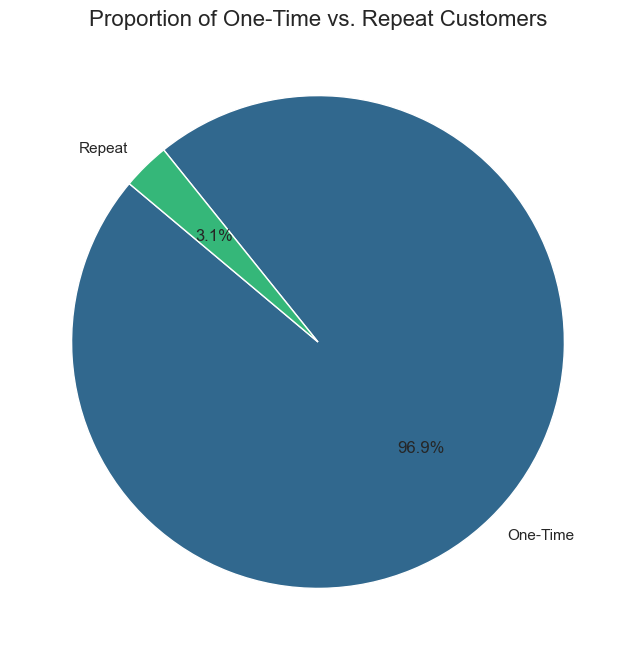

In [ ]:
from src.plotting_utils import plot_pie_chart

# Calculate the number of orders per customer
orders_per_customer = master_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
orders_per_customer.rename(columns={'order_id': 'num_orders'}, inplace=True)

# Classify customers
orders_per_customer['customer_type'] = np.where(orders_per_customer['num_orders'] == 1, 'One-Time', 'Repeat')

# Plot the distribution
plot_pie_chart(
    data=orders_per_customer,
    column='customer_type',
    title='Proportion of One-Time vs. Repeat Customers'
)

### Insights:
* **Critical Retention Issue:** The pie chart reveals a stark reality: approximately **97% of customers are one-time buyers**. This is arguably the most critical business challenge uncovered in this analysis.
* **"Leaky Bucket" Problem:** While the business is effective at acquiring new customers, it struggles immensely with retention. This "leaky bucket" means a huge amount of marketing effort is spent on customers who never return. A key strategic focus for the company should be on improving customer loyalty and encouraging repeat purchases.

### 5.2 Payment Method Analysis

Next, let's analyze how customers pay for their orders. We'll look at the popularity of different payment methods and see if there's a difference in the average transaction value for each method.

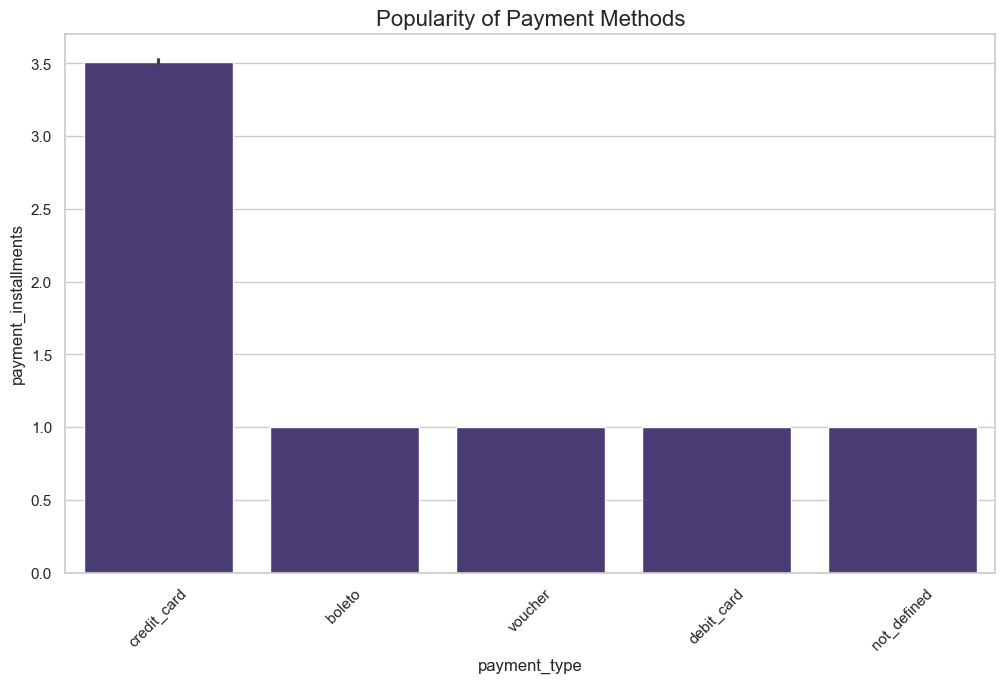

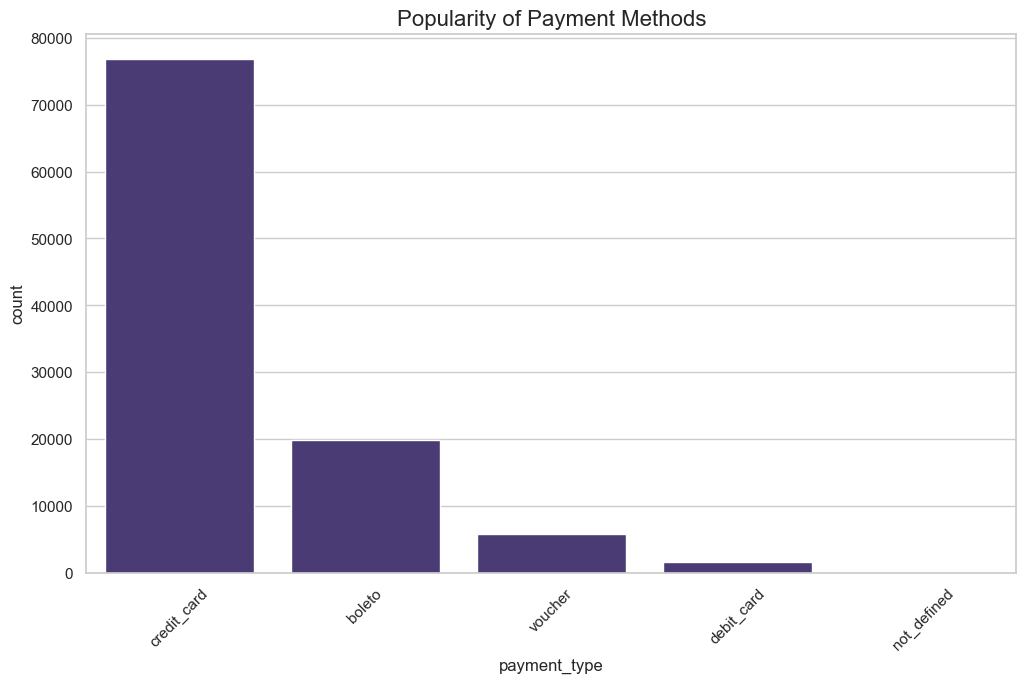

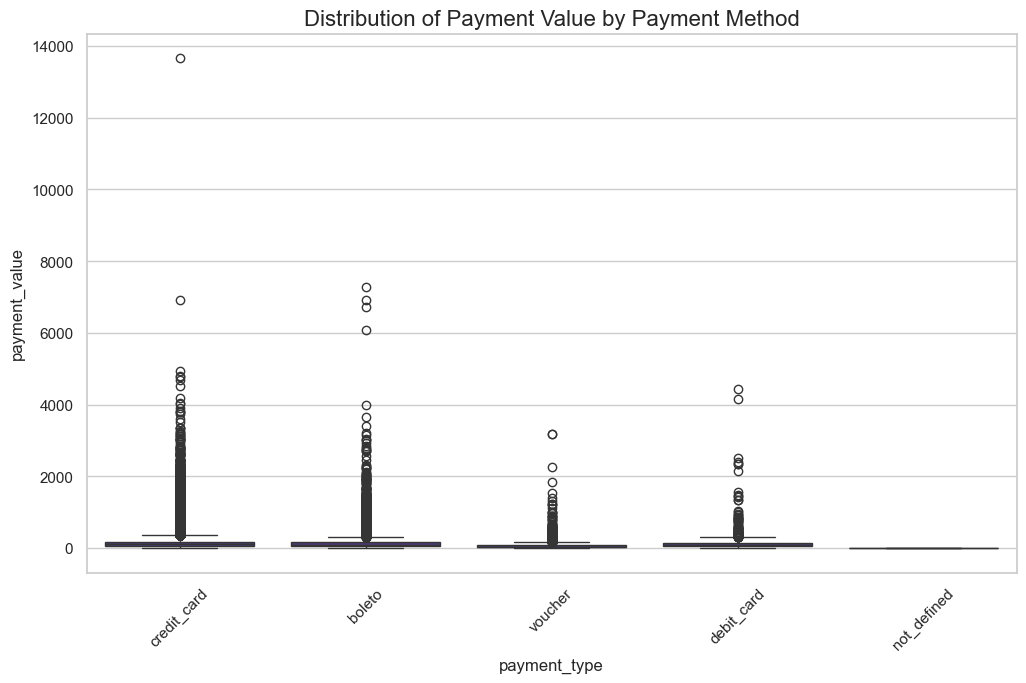

In [ ]:
# Import the functions we'll reuse
from src.plotting_utils import plot_bar, plot_boxplot

# We need to look at the payments table, as one order can have multiple payment methods
payments_df = data['olist_order_payments_dataset']

# --- Popularity of Payment Methods ---
plot_bar(
    data=payments_df,
    x_col='payment_type',
    y_col='payment_installments', # Using a placeholder y_col for countplot-like behavior
    title='Popularity of Payment Methods'
)
# Note: A better way would be to enhance plot_bar to handle value_counts directly.
# For now, we can visualize the value_counts result.
payment_counts = payments_df['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']

plot_bar(
    data=payment_counts,
    x_col='payment_type',
    y_col='count',
    title='Popularity of Payment Methods'
)


# --- Payment Value by Method ---
# A box plot is perfect for comparing the distribution of payment values across different methods.
plot_boxplot(
    data=payments_df,
    x_col='payment_type',
    y_col='payment_value',
    title='Distribution of Payment Value by Payment Method'
)

### Insights:
* **Credit Card Dominance:** Credit card is the most popular payment method by a wide margin, which is typical for e-commerce.
* **Installments Drive Value:** The box plot shows that credit card transactions have a significantly higher median value and a much wider distribution than other methods. This is likely driven by the availability of installment payments (`payment_installments`), which enable customers to make larger purchases.
* **Local Payment Methods:** The presence of `boleto` (a popular Brazilian cash-based payment method) is significant and highlights the need to cater to local payment preferences.

## 6. Delivery Performance Analysis

In this final section of our EDA, we'll analyze the operational performance of the delivery process. Slow or unpredictable shipping can lead to poor reviews and lost customers. We will investigate:
* What is the average actual delivery time?
* How accurate are the estimated delivery dates?
* Does delivery performance vary by customer location?
* Is there a relationship between shipping cost (`freight_value`) and delivery speed?

### 6.1 Calculating Delivery Metrics

First, we need to create our performance metrics. We'll calculate the actual time it takes from purchase to delivery and compare it to the estimated time. We will filter for delivered orders to ensure our calculations are based on completed journeys.

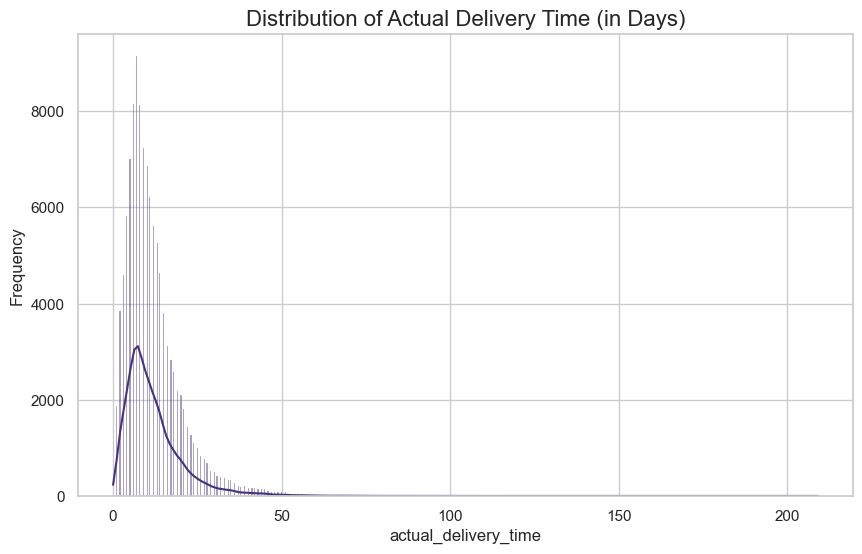

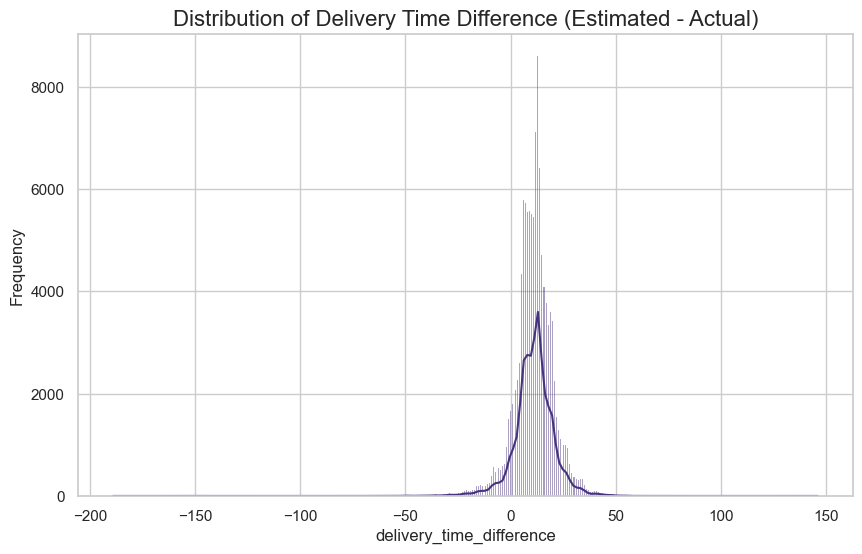

Delivery metrics calculated.


In [ ]:
from src.plotting_utils import plot_histogram

# Filter for delivered orders and drop rows with missing time data
delivered_df = master_df[master_df['order_status'] == 'delivered'].dropna(
    subset=['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
)

# Calculate actual delivery time in days
delivered_df['actual_delivery_time'] = (delivered_df['order_delivered_customer_date'] - delivered_df['order_purchase_timestamp']).dt.days

# Calculate the difference between estimated and actual delivery
# A positive value means the order arrived early; a negative value means it was late.
delivered_df['delivery_time_difference'] = (delivered_df['order_estimated_delivery_date'] - delivered_df['order_delivered_customer_date']).dt.days

# --- Visualize the Distributions ---
plot_histogram(
    data=delivered_df,
    column='actual_delivery_time',
    title='Distribution of Actual Delivery Time (in Days)'
)

plot_histogram(
    data=delivered_df,
    column='delivery_time_difference',
    title='Distribution of Delivery Time Difference (Estimated - Actual)'
)

print("Delivery metrics calculated.")

### 6.2 Delivery Performance by State

Next, let's see if delivery performance is consistent across Brazil. We'll use a box plot to compare the distribution of actual delivery times for the top 15 states with the most orders. This will show us both the average speed and the reliability of delivery in different regions.

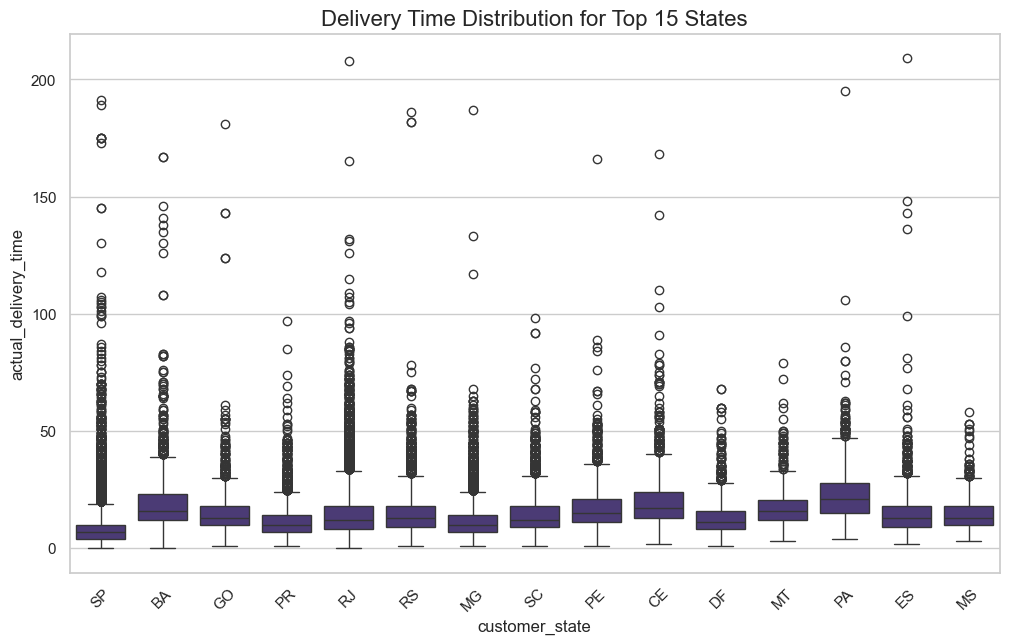

In [ ]:
from src.plotting_utils import plot_boxplot

# Find the top 15 states by order count
top_15_states = delivered_df['customer_state'].value_counts().nlargest(15).index

# Filter the DataFrame to include only these top states
top_states_df = delivered_df[delivered_df['customer_state'].isin(top_15_states)]

# Create the box plot
plot_boxplot(
    data=top_states_df,
    x_col='customer_state',
    y_col='actual_delivery_time',
    title='Delivery Time Distribution for Top 15 States'
)

### Insights:
* **Exceeding Expectations:** The `delivery_time_difference` histogram is heavily skewed to the positive side, meaning most orders arrive **well before their estimated delivery date**. This is a major operational strength and a likely driver of positive customer satisfaction.
* **Geographic Disparity:** While overall performance is good, the box plot shows that delivery is not uniform across Brazil. Delivery to the primary state of São Paulo (SP) is fast and reliable (a tight box plot). In contrast, states further away, like Bahia (BA) and Pernambuco (PE), have longer average delivery times and much greater variability (a wider box and more outliers). This inconsistency in customer experience across regions is a key area for logistical improvement.

## EDA Conclusion

This concludes our deep-dive Exploratory Data Analysis. We have investigated the data from multiple angles: geographic, product, temporal, customer behavior, and logistics. We have a much deeper understanding of the Olist marketplace, its strengths (e.g., high early delivery rate), and its challenges (e.g., a large base of one-time buyers).

These insights are valuable on their own and provide a solid foundation for the next phase: predictive modeling.